In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from IPython.display import display # Grafikleri göstermek için
import matplotlib.pyplot as plt

In [ ]:
# Deutsch Algoritması: f(x) = x (Balanced/Dengeli Fonksiyon)
circuit = QuantumCircuit(2, 1) # 2 Kübit, 1 Klasik Bit

In [3]:
# Hazırlık (q0 -> H, q1 -> X sonra H)
circuit.h(0)
circuit.x(1)
circuit.h(1)
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [4]:
# Oracle (Balanced Fonksiyon: CNOT)
# Eğer q0 '1' ise q1'i çevir. Bu "Phase Kickback" yaratır.
circuit.cx(0, 1)
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [5]:
# Sonuç (q0 -> H ve Ölçüm)
circuit.h(0)
circuit.barrier()
circuit.measure(0, 0)

Deutsch Algoritması Devresi:


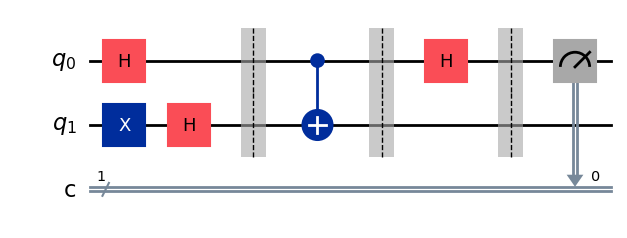

In [6]:
print("Deutsch Algoritması Devresi:")
display(circuit.draw(output='mpl'))

In [ ]:
print("\n--- Yerel Simülatör Başlatılıyor ---")
simulator = AerSimulator()
t_circ = transpile(circuit, simulator)


--- Yerel Simülatör Başlatılıyor ---


In [ ]:
result_sim = simulator.run(t_circ, shots=1024).result()
counts_sim = result_sim.get_counts()

Simülasyon Sonucu: {'1': 1024}


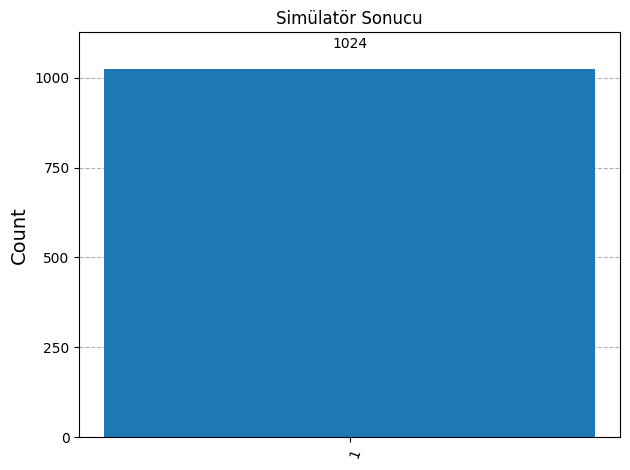

In [9]:
print("Simülasyon Sonucu:", counts_sim)
display(plot_histogram(counts_sim, title="Simülatör Sonucu"))

In [ ]:
print("\n--- Gerçek Donanım Bağlantısı ---")

service = QiskitRuntimeService()

# Tüm Cihazların Durumunu Listele (Eski kodunuzdaki loop'un modern hali)
print(f"{'Cihaz Adı':<20} | {'Sıra':<5} | {'Kübit':<5}")
print("-" * 40)


--- Gerçek Donanım Bağlantısı ---


qiskit_runtime_service.__init__:WARNING:2025-12-28 19:06:59,256: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: lab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Cihaz Adı            | Sıra  | Kübit
----------------------------------------


In [12]:
# Sadece gerçek cihazları alıyoruz (simulator=False)
for backend in service.backends(simulator=False):
    try:
        # Cihazın adını, sıradaki iş sayısını ve kübit sayısını al
        name = backend.name
        pending = backend.status().pending_jobs
        n_qubits = backend.num_qubits
        print(f"{name:<20} | {pending:<5} | {n_qubits:<5}")
    except:
        pass

qiskit_runtime_service.backends:WARNING:2025-12-28 19:07:13,471: Loading instance: lab, plan: open


ibm_fez              | 0     | 156  
ibm_torino           | 0     | 133  
ibm_marrakesh        | 7577  | 156  


In [ ]:
backend = service.least_busy(simulator=False, operational=True)
print(f"\nSeçilen En İyi Cihaz: {backend.name}")

qiskit_runtime_service.backends:WARNING:2025-12-28 19:07:20,795: Loading instance: lab, plan: open
qiskit_runtime_service.backends:WARNING:2025-12-28 19:07:21,576: Using instance: lab, plan: open



Seçilen En İyi Cihaz: ibm_fez


In [ ]:
# Devreyi O Cihaz İçin Transpile Et
transpiled_circuit = transpile(circuit, backend)

In [ ]:
# Sampler V2 ile Gönder ( execute(...) ARTIK YOK )
sampler = Sampler(mode=backend)
print(f"İş {backend.name} cihazına gönderiliyor...")

job = sampler.run([transpiled_circuit], shots=1024)
print(f"Job ID: {job.job_id()}")

İş ibm_fez cihazına gönderiliyor...
Job ID: d58lbhjht8fs73a3sjcg


In [ ]:
# Sonuçları Al
result_real = job.result()
# İlk devrenin (0. index) sonuçlarını 'c' register'ından çekiyoruz
counts_real = result_real[0].data.c.get_counts()

Gerçek Donanım Sonucu: {'1': 997, '0': 27}


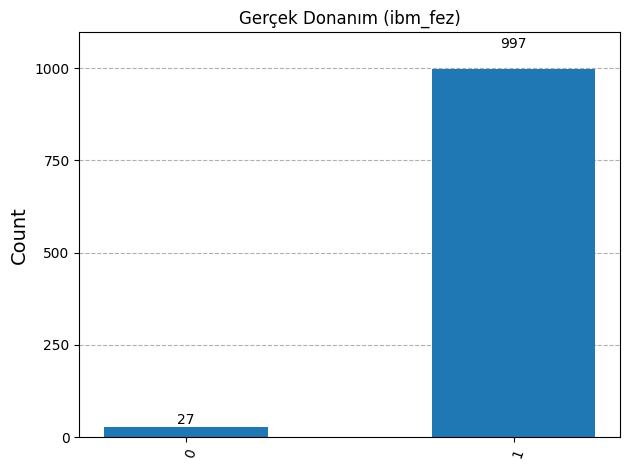

In [17]:
print("Gerçek Donanım Sonucu:", counts_real)
display(plot_histogram(counts_real, title=f"Gerçek Donanım ({backend.name})"))